In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
datos = pd.read_csv("Datos SINAICA.csv", encoding='latin1', engine='python')
datos.dropna(inplace=True)
datos.head()

# if no missing values
# binnig
n = 6
datos["bin"] = np.arange(len(datos))//n   #for every 8 hours; es la divisiòn entera
datos['binned_8h']=datos.groupby("bin")['Concentraciones horarias'].transform('mean')
datos['Fecha'] = pd.to_datetime(datos['Fecha'])
# normalmente en series de tiempo el indice es la fecha
#datos.set_index('Fecha', inplace=True)
#datos.head()

Text(0, 0.5, 'Concentration')

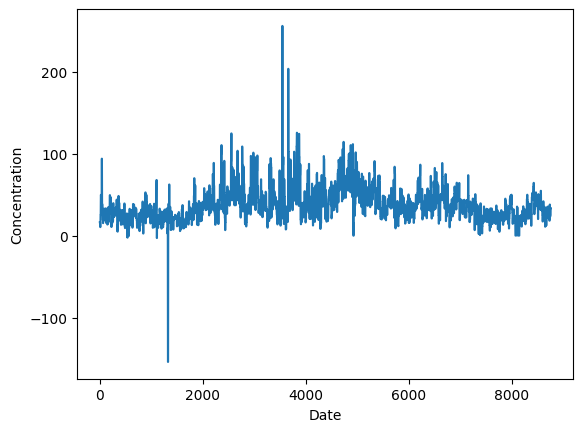

In [ ]:
plt.plot(datos.index, datos['binned_8h'])
plt.xlabel('Date')
plt.ylabel('Concentration')


In [ ]:
#missing values

counts = datos.groupby('Fecha').size()
#percentage of bad days
ratio = len(counts[counts!=24])/len(counts)

good_days = counts[counts ==24].index
good_days

datos_good = datos[datos['Fecha'].isin(good_days)].copy()
datos_good

,Parmetro,Fecha,Hora,Concentraciones horarias,Unidad,bin,binned_8h
1,PM10,2025-08-01,23:00 - 0:00,27.0,µg/m_,0,16.333333
2,PM10,2025-08-01,0:00 - 1:00,34.0,µg/m_,0,16.333333
3,PM10,2025-08-01,1:00 - 2:00,5.0,µg/m_,0,16.333333
4,PM10,2025-08-01,2:00 - 3:00,-7.0,µg/m_,0,16.333333
5,PM10,2025-08-01,3:00 - 4:00,20.0,µg/m_,0,16.333333
...,...,...,...,...,...,...,...
8748,PM10,2026-08-01,18:00 - 19:00,7.0,µg/m_,1457,25.500000
8749,PM10,2026-08-01,19:00 - 20:00,36.0,µg/m_,1458,33.500000
8750,PM10,2026-08-01,20:00 - 21:00,28.0,µg/m_,1458,33.500000
8751,PM10,2026-08-01,21:00 - 22:00,20.0,µg/m_,1458,33.500000


Text(0, 0.5, 'Concentration')

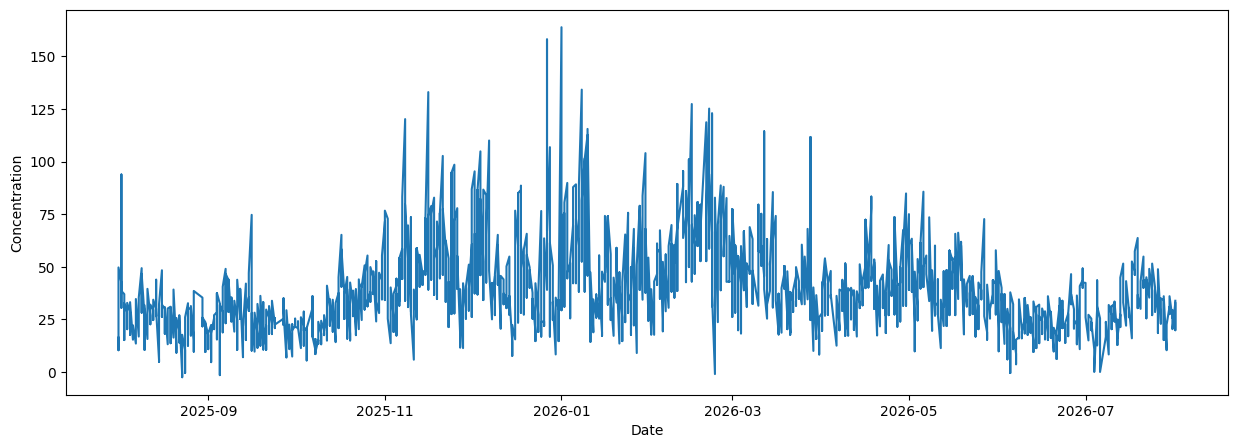

In [ ]:
datos = pd.read_csv("Datos SINAICA.csv", encoding='latin1', engine='python')
datos.dropna(inplace=True)

counts = datos.groupby('Fecha').size()
good_days = counts[counts ==24].index

datos_good = datos[datos['Fecha'].isin(good_days)].copy()
datos_good
# binnig
n = 6
datos_good["bin"] = np.arange(len(datos_good))//n   #for every 8 hours
    datos_good['binned_8h']=datos_good.groupby("bin")['Concentraciones horarias'].transform('mean')
datos_good['Fecha'] = pd.to_datetime(datos_good['Fecha'])


plt.figure(figsize=(15,5))
plt.plot(datos_good['Fecha'], datos_good['binned_8h'])
plt.xlabel('Date')
plt.ylabel('Concentration')

In [ ]:
datos['start_hour'] = (datos['Hora'].str.split('-').str[0].str.strip())
datos['hour_number'] = (datos['start_hour'].str.split(':').str[0].astype(int))
expected = set(range(24))

for date,group in datos.groupby('Fecha'):
  observed=set(group['hour_number'])
  missing = expected - observed
  if missing:
    print(date, 'missing', sorted(missing))

2025-08-28 missing [10, 11, 12, 13, 14]
2025-08-29 missing [14, 15, 16]
2025-09-25 missing [10, 11, 12]
2025-09-26 missing [15, 16, 17, 18, 19, 20, 21]
2025-10-06 missing [15]
2026-02-11 missing [0]
2026-02-19 missing [10, 11, 12, 13, 14, 15]
2026-03-09 missing [14, 15]
2026-04-05 missing [1]
2026-07-07 missing [13, 14, 15]


In [ ]:
datos

,Parmetro,Fecha,Hora,Concentraciones horarias,Unidad,start_hour,hour_number
1,PM10,2025-08-01,23:00 - 0:00,27.0,µg/m_,23:00,23
2,PM10,2025-08-01,0:00 - 1:00,34.0,µg/m_,0:00,0
3,PM10,2025-08-01,1:00 - 2:00,5.0,µg/m_,1:00,1
4,PM10,2025-08-01,2:00 - 3:00,-7.0,µg/m_,2:00,2
5,PM10,2025-08-01,3:00 - 4:00,20.0,µg/m_,3:00,3
...,...,...,...,...,...,...,...
8748,PM10,2026-08-01,18:00 - 19:00,7.0,µg/m_,18:00,18
8749,PM10,2026-08-01,19:00 - 20:00,36.0,µg/m_,19:00,19
8750,PM10,2026-08-01,20:00 - 21:00,28.0,µg/m_,20:00,20
8751,PM10,2026-08-01,21:00 - 22:00,20.0,µg/m_,21:00,21


In [ ]:
downsampling = datos.groupby('Fecha', as_index=False)['Concentraciones horarias'].mean()
downsampling = downsampling.rename(columns={'Concentraciones horarias': 'downsamplig'})
downsampling


,Fecha,downsamplig
0,2025-08-01,25.333333
1,2025-08-02,51.250000
2,2025-08-03,26.083333
3,2025-08-04,26.750000
4,2025-08-05,25.000000
...,...,...
361,2026-07-28,26.833333
362,2026-07-29,15.791667
363,2026-07-30,30.958333
364,2026-07-31,24.833333


([], [])

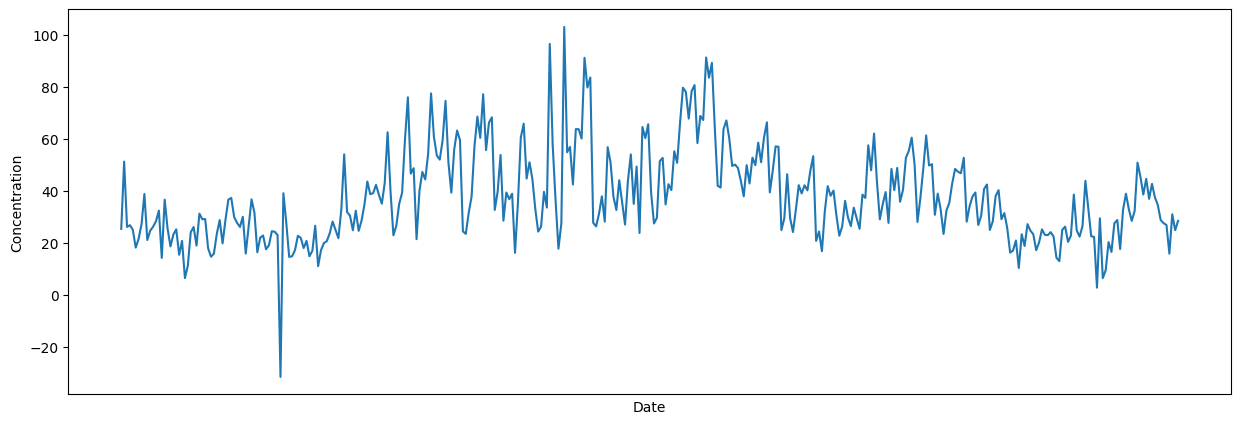

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(downsampling['Fecha'], downsampling['downsamplig'])
plt.xlabel('Date')
plt.ylabel('Concentration')
#plt.xticks(rotation=90)
plt.xticks([])

In [ ]:
np.arange(len(datos))//n

array([   0,    0,    0, ..., 1458, 1458, 1458])